# Baseline Machine Learning Model

## Objective

The objective of this notebook is to build the first machine learning model for predicting drug combination synergy scores.

This notebook loads the feature-engineered dataset, prepares the features, trains a baseline Random Forest model, and evaluates its performance.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/processed/train_features.csv")

print(df.shape)
df.head()

(2754519, 53)


/tmp/ipykernel_2323256/1140135573.py:1: DtypeWarning: Columns (0: PLATE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/train_features.csv")


,COMBODRUGSEQ,SCREENER,STUDY,TESTDATE,PLATE,PANELNBR,CELLNBR,PREFIX1,NSC1,SAMPLE1,...,MolLogP_2,TPSA_2,NumHDonors_2,NumHAcceptors_2,NumRotatableBonds_2,HeavyAtomCount_2,RingCount_2,NumAromaticRings_2,FractionCSP3_2,MolMR_2
0,260496,FG,PZUT00156_86_01_T72,06/23/2011,786-0_1_T72,9,18,S,752,37,...,3.3779,40.54,1.0,2.0,9.0,19.0,1.0,1.0,0.5,80.6688
1,260497,FG,PZUT00156_86_01_T72,06/23/2011,786-0_1_T72,9,18,S,752,37,...,3.3779,40.54,1.0,2.0,9.0,19.0,1.0,1.0,0.5,80.6688
2,260498,FG,PZUT00156_86_01_T72,06/23/2011,786-0_1_T72,9,18,S,752,37,...,3.3779,40.54,1.0,2.0,9.0,19.0,1.0,1.0,0.5,80.6688
3,260499,FG,PZUT00156_86_01_T72,06/23/2011,786-0_1_T72,9,18,S,752,37,...,3.3779,40.54,1.0,2.0,9.0,19.0,1.0,1.0,0.5,80.6688
4,260500,FG,PZUT00156_86_01_T72,06/23/2011,786-0_1_T72,9,18,S,752,37,...,3.3779,40.54,1.0,2.0,9.0,19.0,1.0,1.0,0.5,80.6688


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2754519 entries, 0 to 2754518
Data columns (total 53 columns):
 #   Column               Dtype  
---  ------               -----  
 0   COMBODRUGSEQ         int64  
 1   SCREENER             str    
 2   STUDY                str    
 3   TESTDATE             str    
 4   PLATE                object 
 5   PANELNBR             int64  
 6   CELLNBR              int64  
 7   PREFIX1              str    
 8   NSC1                 int64  
 9   SAMPLE1              int64  
 10  CONCINDEX1           int64  
 11  CONC1                float64
 12  CONCUNIT1            str    
 13  PREFIX2              str    
 14  NSC2                 float64
 15  SAMPLE2              float64
 16  CONCINDEX2           int64  
 17  CONC2                float64
 18  CONCUNIT2            str    
 19  PERCENTGROWTH        float64
 20  PERCENTGROWTHNOTZ    float64
 21  TESTVALUE            float64
 22  CONTROLVALUE         float64
 23  TZVALUE              float64
 24  EXPECTEDG

In [4]:
df.columns.tolist()

['COMBODRUGSEQ',
 'SCREENER',
 'STUDY',
 'TESTDATE',
 'PLATE',
 'PANELNBR',
 'CELLNBR',
 'PREFIX1',
 'NSC1',
 'SAMPLE1',
 'CONCINDEX1',
 'CONC1',
 'CONCUNIT1',
 'PREFIX2',
 'NSC2',
 'SAMPLE2',
 'CONCINDEX2',
 'CONC2',
 'CONCUNIT2',
 'PERCENTGROWTH',
 'PERCENTGROWTHNOTZ',
 'TESTVALUE',
 'CONTROLVALUE',
 'TZVALUE',
 'EXPECTEDGROWTH',
 'SCORE',
 'VALID',
 'PANEL',
 'CELLNAME',
 'MolWt_1',
 'ExactMolWt_1',
 'MolLogP_1',
 'TPSA_1',
 'NumHDonors_1',
 'NumHAcceptors_1',
 'NumRotatableBonds_1',
 'HeavyAtomCount_1',
 'RingCount_1',
 'NumAromaticRings_1',
 'FractionCSP3_1',
 'MolMR_1',
 'MolWt_2',
 'ExactMolWt_2',
 'MolLogP_2',
 'TPSA_2',
 'NumHDonors_2',
 'NumHAcceptors_2',
 'NumRotatableBonds_2',
 'HeavyAtomCount_2',
 'RingCount_2',
 'NumAromaticRings_2',
 'FractionCSP3_2',
 'MolMR_2']

In [5]:
drop_cols = [
    "COMBODRUGSEQ",
    "SCREENER",
    "STUDY",
    "TESTDATE",
    "PLATE",
    "PANELNBR",
    "CELLNBR",
    "PREFIX1",
    "PREFIX2",
    "NSC1",
    "NSC2",
    "SAMPLE1",
    "SAMPLE2",
    "PERCENTGROWTH",
    "PERCENTGROWTHNOTZ",
    "TESTVALUE",
    "CONTROLVALUE",
    "TZVALUE",
    "EXPECTEDGROWTH"
]

model_df = df.drop(columns=drop_cols)

print(model_df.shape)
model_df.head()

(2754519, 34)


,CONCINDEX1,CONC1,CONCUNIT1,CONCINDEX2,CONC2,CONCUNIT2,SCORE,VALID,PANEL,CELLNAME,...,MolLogP_2,TPSA_2,NumHDonors_2,NumHAcceptors_2,NumRotatableBonds_2,HeavyAtomCount_2,RingCount_2,NumAromaticRings_2,FractionCSP3_2,MolMR_2
0,1,1.000000e-07,M,1,0.000001,M,4.0,Y,Renal Cancer,786-0,...,3.3779,40.54,1.0,2.0,9.0,19.0,1.0,1.0,0.5,80.6688
1,1,1.000000e-07,M,2,0.000010,M,-14.0,Y,Renal Cancer,786-0,...,3.3779,40.54,1.0,2.0,9.0,19.0,1.0,1.0,0.5,80.6688
2,1,1.000000e-07,M,3,0.000100,M,-1.0,Y,Renal Cancer,786-0,...,3.3779,40.54,1.0,2.0,9.0,19.0,1.0,1.0,0.5,80.6688
3,2,1.000000e-06,M,1,0.000001,M,5.0,Y,Renal Cancer,786-0,...,3.3779,40.54,1.0,2.0,9.0,19.0,1.0,1.0,0.5,80.6688
4,2,1.000000e-06,M,2,0.000010,M,-16.0,Y,Renal Cancer,786-0,...,3.3779,40.54,1.0,2.0,9.0,19.0,1.0,1.0,0.5,80.6688


In [6]:
model_df.dtypes

CONCINDEX1               int64
CONC1                  float64
CONCUNIT1                  str
CONCINDEX2               int64
CONC2                  float64
CONCUNIT2                  str
SCORE                  float64
VALID                      str
PANEL                      str
CELLNAME                   str
MolWt_1                float64
ExactMolWt_1           float64
MolLogP_1              float64
TPSA_1                 float64
NumHDonors_1           float64
NumHAcceptors_1        float64
NumRotatableBonds_1    float64
HeavyAtomCount_1       float64
RingCount_1            float64
NumAromaticRings_1     float64
FractionCSP3_1         float64
MolMR_1                float64
MolWt_2                float64
ExactMolWt_2           float64
MolLogP_2              float64
TPSA_2                 float64
NumHDonors_2           float64
NumHAcceptors_2        float64
NumRotatableBonds_2    float64
HeavyAtomCount_2       float64
RingCount_2            float64
NumAromaticRings_2     float64
Fraction

In [7]:
model_df = pd.get_dummies(
    model_df,
    columns=[
        "CONCUNIT1",
        "CONCUNIT2",
        "VALID",
        "PANEL",
        "CELLNAME"
    ],
    drop_first=True
)

In [8]:
model_df.select_dtypes(include="object").columns

Index([], dtype='str')

In [9]:
X = model_df.drop(columns="SCORE")
y = model_df["SCORE"]

print(X.shape)
print(y.shape)

(2754519, 95)
(2754519,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2203615, 95)
(550904, 95)


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Training Completed!")

Training Completed!


In [12]:
y_pred = rf.predict(X_test)

print(y_pred[:10])

[ -2.46        -5.22        -1.08         3.26        -9.27
  -2.61       -20.79        -4.39        -2.98        -4.92916667]


In [13]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)

RMSE : 9.475766884822608
MAE  : 6.3012210745153
R²   : 0.4202823217756817


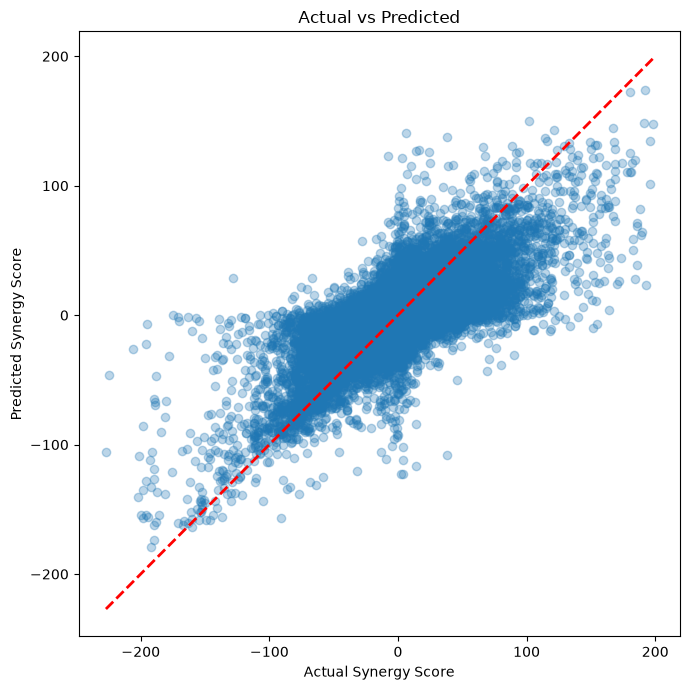

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Synergy Score")
plt.ylabel("Predicted Synergy Score")
plt.title("Actual vs Predicted")

plt.tight_layout()

plt.savefig(
    "../figures/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
plt.savefig(
    "../figures/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [15]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
0,CONCINDEX1,0.053489
1,CONC1,0.048377
6,MolLogP_1,0.031336
19,TPSA_2,0.030321
15,MolMR_1,0.027640
3,CONC2,0.026982
7,TPSA_1,0.023847
14,FractionCSP3_1,0.023438
18,MolLogP_2,0.023191
2,CONCINDEX2,0.022704


In [16]:
feature_importance.to_csv(
    "../results/random_forest_feature_importance.csv",
    index=False
)

print("Feature importance saved!")

Feature importance saved!


In [17]:
import joblib

joblib.dump(
    rf,
    "../models/random_forest_baseline.pkl"
)

print("Baseline model saved!")

Baseline model saved!


In [18]:
print(rf.n_features_in_)

95


In [19]:
X = model_df.drop(columns="SCORE")

In [20]:
print("=" * 50)
print("df shape:", df.shape)
print("model_df shape:", model_df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of X columns:", len(X.columns))
print("=" * 50)

df shape: (2754519, 53)
model_df shape: (2754519, 96)
X shape: (2754519, 95)
y shape: (2754519,)
Number of X columns: 95


In [21]:
print("Model expects:", rf.n_features_in_)
print("X has:", X.shape[1])

Model expects: 95
X has: 95
